# FWI com Unets

In [1]:
# %env XLA_FLAGS=--xla_gpu_cuda_data_dir=/home/fmn/miniconda3/pkgs/cuda-nvvm-tools-12.9.86-h4bc722e_2
# %env TF_ENABLE_ONEDNN_OPTS=0

In [ ]:
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import clear_output


import numpy as np

import tensorflow as tf
from tensorflow.keras import  layers, Model

from geod67lib.unet import create_migration_map
from geod67lib.normalization import create_normalization_transforms
from geod67lib.plotting import plot_image, plot_seismogram
from geod67lib.wavefield import WaveSolverLayer, AquisitionParameters, generate_damp_mask



## Modelo de velocidade e imagem migrada

In [ ]:
# shape = (1024, 512)
# shape = (256, 256)
# spacing = (10, 10)
shape = (128, 128)
spacing = (20, 20)

width, height = (shape[0] - 1)*spacing[0], (shape[1] - 1)*spacing[1]

In [ ]:
vp_true = np.fromfile(f'./data/marmo_vp_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))
vp_0 = np.fromfile(f'./data/vp0_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))
zeta = np.fromfile(f'./data/mig_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))

In [ ]:
vpmin = vp_true.min()*.9
vpmax = vp_true.max()*1.1

vpmin, vpmax

(1.35, 4.894999790191651)

In [ ]:
normalize, denormalize = create_normalization_transforms(vpmin, vpmax)

In [ ]:
m_0 = normalize(tf.constant(vp_0))

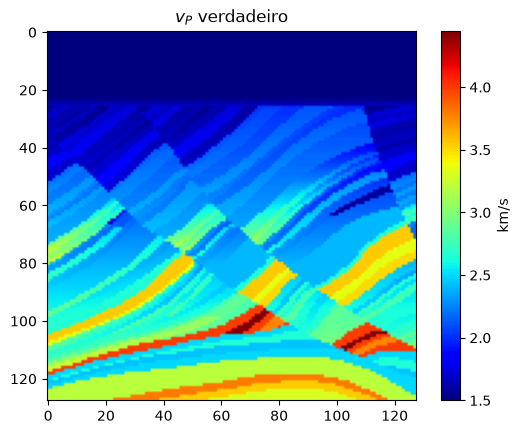

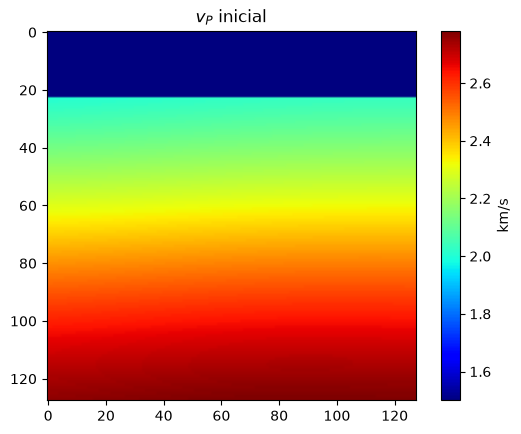

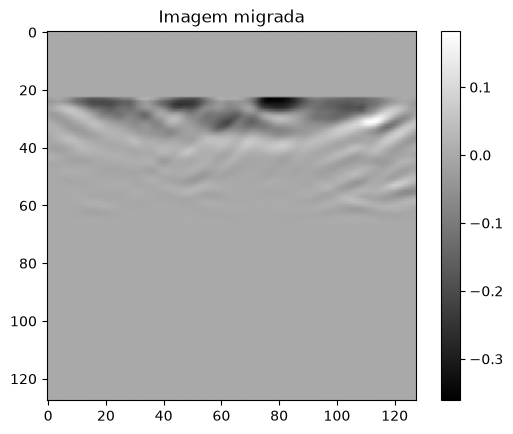

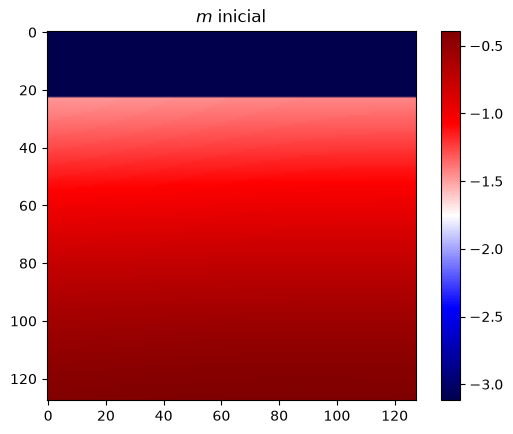

In [ ]:
plot_image(vp_true, title='$v_P$ verdadeiro', label='km/s')
plot_image(vp_0, title='$v_P$ inicial', label='km/s')
plot_image(zeta, title='Imagem migrada', cmap='gray')
plot_image(m_0.numpy(), title='$m$ inicial', cmap='seismic')

## Construção da Rede

In [ ]:
migmap = create_migration_map(*shape)

In [ ]:
zeta_in = tf.constant(zeta)
np.min(zeta_in), np.max(zeta_in)

(-0.36106756, 0.18292712)

In [ ]:
dm = migmap(zeta_in)
np.min(dm), np.max(dm)

(-0.013492279, 0.019664347)

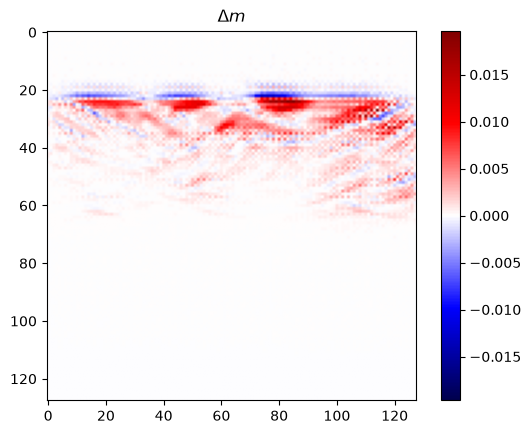

In [ ]:
d = dm.numpy()
d = d - np.median(d)
plot_image(d, cmap='seismic', vmin=-np.abs(d).max(), vmax=np.abs(d).max(), title='$\\Delta m$')

## Operador de modelagem

In [ ]:
nbl = 20

In [ ]:
ap = AquisitionParameters.load('./data/aquisition-params.json')

nrec = ap.nrec
nsrc = ap.nsrc
nt = ap.nt

src_positions = ap.src_positions
ap.src_positions = np.zeros((1, 2))

In [ ]:
vp0_pad = np.pad(vp_0[0, :, :, 0], nbl, mode='edge')
vp0_pad = vp0_pad.reshape((1, *vp0_pad.shape, 1))
damp_mask = generate_damp_mask(vp0_pad, nbl)

In [ ]:
damp_mask.shape

(1, 168, 168, 1)

## Dado observado

In [ ]:
dobs = np.fromfile(f'./data/dobs_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape(nsrc, nrec, nt)

In [ ]:
slider = widgets.IntSlider(min=0, max=nsrc-1, description='Shot index')
@widgets.interact(idx=slider)
def plot_seismogram_interact(idx):
    plot_seismogram(dobs[idx], width, ap.tn)

interactive(children=(IntSlider(value=0, description='Shot index', max=4), Output()), _dom_classes=('widget-in…

## Inversão

In [ ]:
migmap.input, migmap.output

(<KerasTensor shape=(None, 128, 128, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor>,
 <KerasTensor shape=(None, 128, 128, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_40>)

In [ ]:
dm = migmap.output
m = layers.Add()([dm, m_0])
out = WaveSolverLayer(ap, damp_mask, src_positions, spacing=spacing)(m)
out

<KerasTensor shape=(5, 128, 750), dtype=float32, sparse=False, ragged=False, name=keras_tensor_42>

In [ ]:
model = Model(inputs=migmap.input,outputs=out,name='train_net')
model

<Functional name=train_net, built=True>

In [ ]:
model.output

<KerasTensor shape=(5, 128, 750), dtype=float32, sparse=False, ragged=False, name=keras_tensor_42>

In [ ]:
# with tf.GradientTape() as g:
#     dcalc = model(zeta_in)
#     res = dcalc - dobs
#     phi = tf.reduce_mean(tf.square(res))

#     grad = g.gradient(phi, model.variables[0])
# grad

In [ ]:
model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=[
        tf.keras.metrics.MeanSquaredError()
    ]
)

In [ ]:
x_train = zeta
y_train = dobs.reshape((1, *dobs.shape))

: 

In [ ]:
history = model.fit(
    x_train,
    y_train,
    batch_size=1,
    verbose=2,
    epochs=1
)

In [ ]:
dm = migmap(zeta)

In [ ]:
dm